# docdistance API - E2E Validation

**Author**: Konrad Jelen (kj)<br>
**Pipeline stage**: validation - exercise the shipped `docdistance` package end-to-end

This notebook validates the `docdistance` library against the same executive-summary fixtures used in
`notebooks/04-kj-wmd-document-distance.ipynb`. It calls only the public API - no re-implemented math - and
checks that the packaged pipeline reproduces the experiment: every gold summary ranks closer to the anchor
than every adversarial one, with zero ordinality violations. It also exercises the source-conditioned mode
and confirms the two encoder backends agree.

## Approach

1. **Load the pipeline** - `DocDistance(backend="openvino")` loads the segmenter and encoder once, then embeds every fixture
2. **Reproduce the ordinality** - distance from the gold anchor to all other summaries; count gold-vs-adversarial violations (target 0/24)
3. **Verdict via the API** - `document_distance` on representative pairs, reading the `DistanceResult` verdict
4. **Backend agreement** - openvino INT8 vs torch on the same pairs; the ordering must be preserved
5. **Source-conditioned** - `source_conditioned_distance` on the shared IBM article; the D_sel selection axis separates faithful from drifting picks

## Outputs

- A reproduced verdict table (closeness per tier) and the 0/24 ordinality check, through the library
- A tier bar chart and the backend-agreement scatter
- In-notebook conclusions grounded in the cell outputs


## GPU Selection and Environment

Pin the GPU before any torch import (the torch backend uses it); the openvino backend is CPU-only.

In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # RTX 5000 Ada (sm_89)
os.environ["HF_HUB_OFFLINE"] = "1"        # models already cached; the library never downloads here
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
print("env pinned; models offline")

env pinned; models offline


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import contextlib
import io
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table
from rich.panel import Panel

# the library under test - public API only
from docdistance import DocDistance, document_distance, source_conditioned_distance
from docdistance.distance import smd, closeness, DEFAULT_THRESHOLD
import docdistance

import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", category=DeprecationWarning)

console = Console()
sns.set_theme(style="whitegrid")
print("docdistance", docdistance.__version__)

docdistance 1.0.15


## Configuration

The 11-summary fixture set built from one IBM AI-adoption article: a gold tier plus two adversarial tiers.

In [3]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"
SOURCE_FILE = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/source/source-article.md"

DOCS = [
    ("exec-summary-gold-opus-4-8.md",     "gold",   "gold"),   # reference anchor
    ("exec-summary-gold-2-opus-4-8.md",   "gold-2", "gold"),
    ("exec-summary-1-opus-4-8.md",        "v1",     "gold"),
    ("exec-summary-2-opus-4-8.md",        "v2",     "gold"),
    ("exec-summary-opus-4-8.md",          "opus",   "gold"),
    ("exec-summary-sonnet-4-6.md",        "sonnet", "gold"),
    ("exec-summary-haiku-4-5.md",         "haiku",  "gold"),
    ("exec-summary-adv1-a-sonnet-4-6.md", "adv1-a", "adv1"),
    ("exec-summary-adv1-b-sonnet-4-6.md", "adv1-b", "adv1"),
    ("exec-summary-adv2-a-haiku-4-5.md",  "adv2-a", "adv2"),
    ("exec-summary-adv2-b-haiku-4-5.md",  "adv2-b", "adv2"),
]
REFERENCE = "gold"
TIER_COLOR = {"gold": "#2ca02c", "adv1": "#ff7f0e", "adv2": "#d62728"}
tier_of = {lbl: t for _, lbl, t in DOCS}

cfg = Table.grid(padding=(0, 2))
cfg.add_column(style="bold cyan"); cfg.add_column()
cfg.add_row("Fixtures", f"{len(DOCS)} summaries + 1 source")
cfg.add_row("Reference", REFERENCE)
cfg.add_row("Backend", "openvino INT8 (CPU)")
cfg.add_row("Verdict threshold", f"{DEFAULT_THRESHOLD:.3f} closeness")
console.print(Panel(cfg, title="[bold]Configuration[/bold]", border_style="cyan", expand=False))

╭────────────── Configuration ───────────────╮
│ Fixtures           11 summaries + 1 source │
│ Reference          gold                    │
│ Backend            openvino INT8 (CPU)     │
│ Verdict threshold  0.725 closeness         │
╰────────────────────────────────────────────╯

## Load the pipeline and embed the fixtures

`DocDistance` loads the SAT segmenter and the INT8 encoder once; `.embed` returns L2-normalized statement vectors per document.

In [4]:
with contextlib.redirect_stderr(io.StringIO()):   # mute the py3.13 fork() advisory from the encoder
    dd = DocDistance(backend="openvino")
    emb = {lbl: dd.embed(SUMMARY_DIR / fname) for fname, lbl, _ in DOCS}
print({lbl: emb[lbl].shape for lbl in ("gold", "adv2-a")})

{'gold': (12, 768), 'adv2-a': (13, 768)}


## Reproduce the validated ordinality

Distance from the gold anchor to every other summary, ordered. The guardrail is the gold-vs-adversarial ordinality: every gold must rank below every adversarial. nb04 reported 0/24 - the library must match.

In [5]:
d = {lbl: smd(emb[lbl], emb[REFERENCE]) for _, lbl, _ in DOCS if lbl != REFERENCE}
order = sorted(d, key=d.get)

tbl = Table(title="Distance to the gold anchor (through the library)", header_style="bold cyan")
tbl.add_column("doc"); tbl.add_column("tier"); tbl.add_column("SMD", justify="right")
tbl.add_column("closeness", justify="right"); tbl.add_column("verdict")
for lbl in order:
    sim = "similar" if closeness(d[lbl]) >= DEFAULT_THRESHOLD else "not similar"
    style = "green" if sim == "similar" else "red"
    tbl.add_row(lbl, tier_of[lbl], f"{d[lbl]:.4f}", f"{closeness(d[lbl])*100:.1f}%", f"[{style}]{sim}[/{style}]")
console.print(tbl)

gold = [l for l in d if tier_of[l] == "gold"]
adv = [l for l in d if tier_of[l] in ("adv1", "adv2")]
viol = sum(1 for g in gold for a in adv if d[g] >= d[a])
min_gold = min(closeness(d[g]) for g in gold) * 100
max_adv = max(closeness(d[a]) for a in adv) * 100
console.print(f"[bold]ordinality violations: {viol} / {len(gold)*len(adv)}[/bold]  "
              f"(min gold {min_gold:.1f}% vs max adversarial {max_adv:.1f}%)")
assert viol == 0, "library must reproduce the 0/24 ordinality from nb04"
print("PASS - the library reproduces the experiment")

 Distance to the gold anchor (through the library)  
┏━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ doc    ┃ tier ┃    SMD ┃ closeness ┃ verdict     ┃
┡━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ gold-2 │ gold │ 0.2593 │     81.7% │ similar     │
│ v1     │ gold │ 0.3057 │     78.4% │ similar     │
│ opus   │ gold │ 0.3474 │     75.4% │ similar     │
│ v2     │ gold │ 0.3498 │     75.3% │ similar     │
│ sonnet │ gold │ 0.3633 │     74.3% │ similar     │
│ haiku  │ gold │ 0.3861 │     72.7% │ similar     │
│ adv2-b │ adv2 │ 0.3933 │     72.2% │ not similar │
│ adv2-a │ adv2 │ 0.4189 │     70.4% │ not similar │
│ adv1-a │ adv1 │ 0.4430 │     68.7% │ not similar │
│ adv1-b │ adv1 │ 0.4609 │     67.4% │ not similar │
└────────┴──────┴────────┴───────────┴─────────────┘

ordinality violations: 0 / 24  (min gold 72.7% vs max adversarial 72.2%)

PASS - the library reproduces the experiment


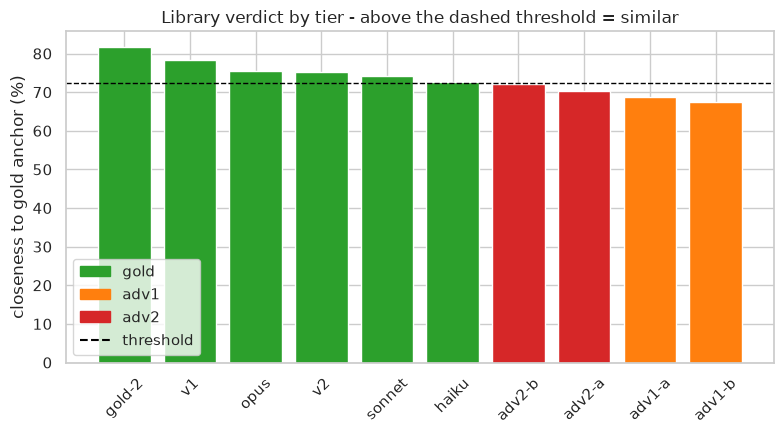

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
vals = [closeness(d[l]) * 100 for l in order]
colors = [TIER_COLOR[tier_of[l]] for l in order]
ax.bar(order, vals, color=colors)
ax.axhline(DEFAULT_THRESHOLD * 100, color="black", ls="--", lw=1)
ax.set_ylabel("closeness to gold anchor (%)")
ax.set_title("Library verdict by tier - above the dashed threshold = similar")
ax.tick_params(axis="x", rotation=45)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TIER_COLOR.values()]
ax.legend(handles + [plt.Line2D([0], [0], color="black", ls="--")],
          list(TIER_COLOR) + ["threshold"])
plt.tight_layout(); plt.show()

## Verdict through the one-shot API

`document_distance` loads and scores in one call and returns a `DistanceResult` (the JSON-ready record the CLI emits).

In [7]:
anchor = SUMMARY_DIR / "exec-summary-gold-opus-4-8.md"
for other, expect in [("exec-summary-gold-2-opus-4-8.md", "similar"),
                      ("exec-summary-adv2-a-haiku-4-5.md", "not similar"),
                      ("exec-summary-adv1-a-sonnet-4-6.md", "not similar")]:
    r = document_distance(anchor, SUMMARY_DIR / other)
    flag = "OK" if r.verdict == expect else "MISMATCH"
    print(f"{other:38} SMD {r.smd:.4f}  closeness {r.closeness*100:5.1f}%  -> {r.verdict:11} [{flag}]")
print("\nDistanceResult.to_dict():", document_distance(anchor, SUMMARY_DIR / "exec-summary-gold-2-opus-4-8.md").to_dict())

exec-summary-gold-2-opus-4-8.md        SMD 0.2593  closeness  81.7%  -> similar     [OK]


exec-summary-adv2-a-haiku-4-5.md       SMD 0.4189  closeness  70.4%  -> not similar [OK]


exec-summary-adv1-a-sonnet-4-6.md      SMD 0.4430  closeness  68.7%  -> not similar [OK]



DistanceResult.to_dict(): {'smd': 0.2592552459488312, 'wcd': 0.09227019548416138, 'rwmd': 0.2453746652851502, 'closeness': 0.8166788575313952, 'threshold': 0.725, 'verdict': 'similar', 'anisotropy': False, 'n_statements_a': 12, 'n_statements_b': 12}


## Backend agreement - openvino INT8 vs torch

The two encoder backends should preserve the ordering. Pearson on the distance-to-anchor vector quantifies the agreement; the torch backend is guarded so a missing model does not fail the notebook.

openvino vs torch distance-to-anchor Pearson r = 0.9991


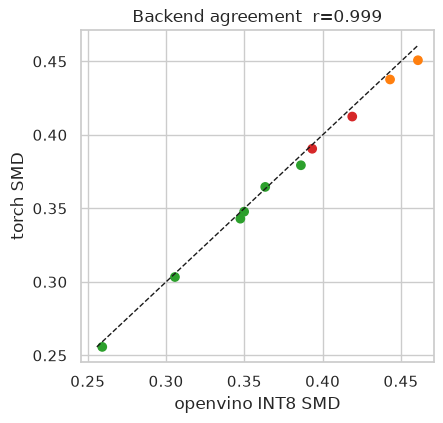

In [8]:
try:
    dd_t = DocDistance(backend="torch")
    emb_t = {lbl: dd_t.embed(SUMMARY_DIR / fname) for fname, lbl, _ in DOCS}
    d_t = {lbl: smd(emb_t[lbl], emb_t[REFERENCE]) for _, lbl, _ in DOCS if lbl != REFERENCE}
    xs = np.array([d[l] for l in order]); ys = np.array([d_t[l] for l in order])
    r = float(np.corrcoef(xs, ys)[0, 1])
    print(f"openvino vs torch distance-to-anchor Pearson r = {r:.4f}")
    fig, ax = plt.subplots(figsize=(4.6, 4.4))
    ax.scatter(xs, ys, c=[TIER_COLOR[tier_of[l]] for l in order])
    lim = [min(xs.min(), ys.min()), max(xs.max(), ys.max())]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel("openvino INT8 SMD"); ax.set_ylabel("torch SMD")
    ax.set_title(f"Backend agreement  r={r:.3f}")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("torch backend unavailable, skipping agreement check:", type(e).__name__, e)

## Source-conditioned distance d(A,B|S) - the second solution

The symmetric SMD above answers "how far apart" with one source-blind number. The library's second distance re-bases the comparison on the shared IBM source article and answers "why they diverge": `D_sel` (selection divergence) measures whether a document covers the same source content, with per-document residuals to the source. Running both solutions over the full fixture is the comparison - the symmetric scalar ranks the tiers but cannot attribute the difference, while the source-conditioned axis names it as selection drift. The orthogonal grounding axis `D_grd` (reranker x NLI - is what it says supported) and the blend that orders fabrication above info-loss live in `notebooks/05-kj-source-conditioned-distance.ipynb`.

In [9]:
# one-shot public API: source_conditioned_distance(a, b, source) -> d_sel + residuals
demo = source_conditioned_distance(anchor, SUMMARY_DIR / "exec-summary-gold-2-opus-4-8.md", SOURCE_FILE)
print(f"source_conditioned_distance(gold, gold-2 | S):  d_sel {demo.d_sel:.4f}  "
      f"residual_a {demo.residual_a:.4f}  residual_b {demo.residual_b:.4f}")

# full-fixture comparison, reusing the loaded pipeline (dd.distance_wrt_source is what the one-shot wraps)
sc = {lbl: dd.distance_wrt_source(anchor, SUMMARY_DIR / fname, SOURCE_FILE)
      for fname, lbl, _ in DOCS if lbl != REFERENCE}

ct = Table(title="two solutions vs the gold anchor - symmetric SMD vs source-conditioned d(A,B|S)",
           header_style="bold cyan")
ct.add_column("doc"); ct.add_column("tier")
ct.add_column("SMD symmetric", justify="right")
ct.add_column("D_sel conditioned", justify="right")
ct.add_column("residual_b", justify="right")
for lbl in sorted(sc, key=lambda l: (tier_of[l], l)):
    ct.add_row(lbl, tier_of[lbl], f"{d[lbl]:.4f}", f"{sc[lbl].d_sel:.4f}", f"{sc[lbl].residual_b:.4f}",
               style=TIER_COLOR[tier_of[lbl]])
console.print(ct)

gold = [l for l in sc if tier_of[l] == "gold"]; adv = [l for l in sc if tier_of[l] != "gold"]
def _means(score):
    return {t: float(np.mean([score[l] for l in sc if tier_of[l] == t])) for t in ("gold", "adv1", "adv2")}
sym_m = _means(d); sel_m = _means({l: sc[l].d_sel for l in sc})
sym_v = sum(1 for g in gold for a in adv if d[g] >= d[a])
sel_v = sum(1 for g in gold for a in adv if sc[g].d_sel >= sc[a].d_sel)
n = len(gold) * len(adv)
console.print(f"[bold]symmetric SMD[/bold]            gold {sym_m['gold']:.3f}  Set1 {sym_m['adv1']:.3f}  Set2 {sym_m['adv2']:.3f}   ({sym_v}/{n} violations)")
console.print(f"[bold]source-conditioned D_sel[/bold]  gold {sel_m['gold']:.3f}  Set1 {sel_m['adv1']:.3f}  Set2 {sel_m['adv2']:.3f}   ({sel_v}/{n} violations)")
print("both rank every gold below every adversarial; the conditioned axis is source-grounded and attributes the divergence to selection")

source_conditioned_distance(gold, gold-2 | S):  d_sel 0.0199  residual_a 0.6851  residual_b 0.6782


       two solutions vs the gold anchor - symmetric SMD vs        
                   source-conditioned d(A,B|S)                    
┏━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ doc    ┃ tier ┃ SMD symmetric ┃ D_sel conditioned ┃ residual_b ┃
┡━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ adv1-a │ adv1 │        0.4430 │            0.0548 │     0.7306 │
│ adv1-b │ adv1 │        0.4609 │            0.0643 │     0.7542 │
│ adv2-a │ adv2 │        0.4189 │            0.0845 │     0.7031 │
│ adv2-b │ adv2 │        0.3933 │            0.0624 │     0.7317 │
│ gold-2 │ gold │        0.2593 │            0.0199 │     0.6782 │
│ haiku  │ gold │        0.3861 │            0.0395 │     0.6988 │
│ opus   │ gold │        0.3474 │            0.0257 │     0.6810 │
│ sonnet │ gold │        0.3633 │            0.0233 │     0.6881 │
│ v1     │ gold │        0.3057 │            0.0258 │     0.6840 │
│ v2     │ gold │        0.3498 │            0.0289 │     0.6956 │
└────────┴──────┴───────────────┴───────────────────┴────────────┘

symmetric SMD            gold 0.335  Set1 0.452  Set2 0.406   (0/24 violations)

source-conditioned D_sel  gold 0.027  Set1 0.060  Set2 0.073   (0/24 violations)

both rank every gold below every adversarial; the conditioned axis is source-grounded and attributes the divergence to selection


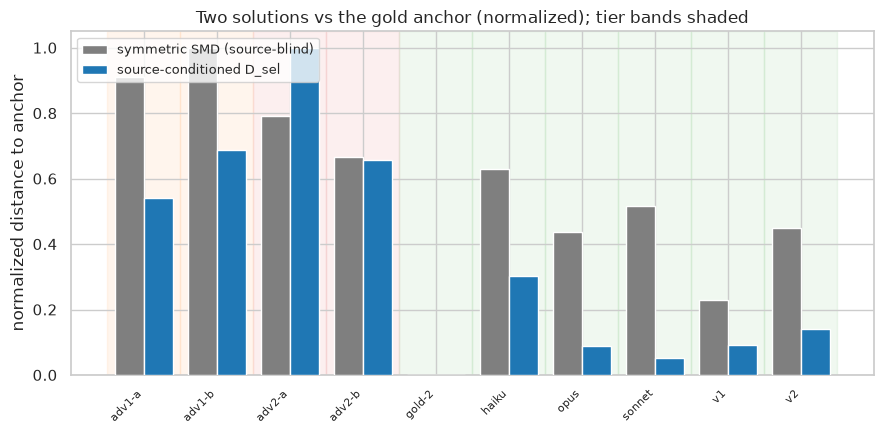

In [10]:
# normalized side-by-side: both solutions rank the tiers; D_sel is conditioned on the source
labs = sorted(sc, key=lambda l: (tier_of[l], l))
def _nrm(vals):
    lo, hi = min(vals), max(vals)
    return [(x - lo) / (hi - lo) if hi > lo else 0.0 for x in vals]
sym_n = _nrm([d[l] for l in labs]); sel_n = _nrm([sc[l].d_sel for l in labs])
x = np.arange(len(labs)); w = 0.4
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, l in enumerate(labs):
    ax.axvspan(i - 0.5, i + 0.5, color=TIER_COLOR[tier_of[l]], alpha=0.07, zorder=0)
ax.bar(x - w / 2, sym_n, w, label="symmetric SMD (source-blind)", color="#7f7f7f", zorder=3)
ax.bar(x + w / 2, sel_n, w, label="source-conditioned D_sel", color="#1f77b4", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(labs, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("normalized distance to anchor"); ax.legend(loc="upper left", fontsize=9)
ax.set_title("Two solutions vs the gold anchor (normalized); tier bands shaded")
plt.tight_layout(); plt.show()

## Conclusions

The library ships two distances and this notebook validates both end to end through the public API.

- **Solution 1 - symmetric SMD** (`document_distance`) - source-blind "how far apart"; reproduces nb04 exactly, `0/24` gold-vs-adversarial ordinality violations, gold-2 the nearest summary, the closeness boundary between the tiers; openvino INT8 and torch backends agree
- **Solution 2 - source-conditioned d(A,B|S)** (`source_conditioned_distance` / `dd.distance_wrt_source`) - re-bases on the shared source and names *why* two documents diverge; `D_sel` (selection) is several times larger for a drifting adversarial than for a second faithful gold and ranks every adversarial above every gold, with per-document residuals to the source
- **What the comparison shows** - both rank the tiers, but the symmetric scalar cannot attribute the difference; the source-conditioned axis says it is selection drift, conditioned on `S`
- **Default is raw embeddings** - anisotropy removal is corpus-level and degenerate on a single pair, so the pairwise API uses raw embeddings, matching nb04's validated verdict
- **The grounding axis is separate** - `D_grd` (reranker x NLI, "is what it says supported") and the E03-H5 blend that orders fabrication above info-loss live in `notebooks/05-kj-source-conditioned-distance.ipynb`; the shipped library covers the selection axis

The packaged `docdistance` is faithful to the validated notebook and ready to drop into a pipeline via the API or CLI - the symmetric scalar for "how far", the source-conditioned axis for "why".